# 09 — Positioning and Crowding

**Chain position:** … → Validation → Forensics → `Crowding` → Construction → Risk

Notebook 08 produced a long list and a short list. Neither asks the question a fund asks
next: **who else is already in this trade?** A crowded long is expensive; a crowded short
is where you get squeezed.

It also does a piece of unglamorous work that notebook 10 cannot proceed without — it emits
the **lot-size and F&O-eligibility table**. That dependency is invisible until you try to
trade the output, and it is why this notebook runs before construction rather than after.

### This is the most fragile notebook in the project

Every endpoint here is undocumented and NSE changes them without notice. The verdicts in
`mkt/derivatives.py` are dated measurements, not assumptions — probed live on 2026-09-08:

| Feature | Verdict |
|---|---|
| Lot sizes (`fo_mktlots.csv`) | ✅ works — the only source that does |
| F&O eligibility (`master-quote`) | ✅ works, ~210 symbols |
| Option chain (`option-chain-v3`) | ✅ works — **requires** an `expiry` argument |
| Futures basis, OI (`snapshot-derivatives-equity`) | ⚠️ only ~25 underlyings, not the Nifty 50 |
| Rollover | ⚠️ approximation — NSE's official figure is not in any public JSON |
| Delivery % (`quote-equity?section=trade_info`) | ❌ **403** — not obtainable |
| `option-chain-equities` (the well-known path) | ❌ returns `{}` with HTTP 200 |

Section 1 prints the health table and the notebook degrades **visibly** rather than
silently. And because `portfolio.lot_table()` carries a dated static fallback,
**notebook 10 runs without this notebook at all** — which is what makes 09 safely
cuttable.

### Crowding has no history, and that is a real limit

A single snapshot gives a level, not a percentile. There is no OI history API — the same
wall notebook 05 hit with FII/DII flows. The response is the same one: every run appends
its snapshot to `data/derivatives_history.csv`, so percentiles become available with use.
On a fresh clone that file has one row. Until it has many, the crowding score below ranks
names **against each other today** and claims nothing more.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard, derivatives as dv,
                 portfolio as pf, indicators as ind, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

health = dv.health_check()
display(health)
n_ok = int((health["status"] == "OK").sum())
if n_ok < len(health):
    print(f"\n{len(health) - n_ok} derivatives source(s) unavailable. Each section below")
    print("checks its own inputs and skips rather than failing the notebook.")

mkt v1.0.0 | run 2026-09-09 10:50 | REFRESH=False | cache=G:\stock market analysis\data\cache


  [retry 1/2] nse trade_info RELIANCE: RuntimeError: HTTP 403, re-warmed session -- waiting 1.5s


  [retry 2/2] nse trade_info RELIANCE: RuntimeError: HTTP 403, re-warmed session -- waiting 3.0s


Derivatives source health: 6/7 OK  (checked 2026-09-09 10:50)


,source,status,rows,secs,note
0,NSE fo_mktlots.csv (lot sizes),OK,1,0.10,
1,NSE master-quote (F&O eligibility),OK,1,0.01,
2,NSE contract-info (expiries),OK,3,0.01,
3,NSE option-chain-v3 (equity),OK,39,0.70,
4,NSE option-chain-v3 (index),OK,87,0.05,
5,NSE futures snapshot,OK,32,0.03,
6,NSE quote-equity trade_info (delivery %),FAILED,0,5.42,"RuntimeError: HTTP 403 -- measured 2026-09-08,..."



1 derivatives source(s) unavailable. Each section below
checks its own inputs and skips rather than failing the notebook.


## 1. Lot sizes and F&O eligibility — what notebook 10 needs

Overnight shorts in India must be stock futures, which trade in **whole lots**. Notebook 10
cannot size a short leg without this table, and `portfolio.assert_implementable()` cannot
fire without it either.

In [2]:
universe = list(config.NIFTY_50)
lots_ok = True
try:
    live_lots = dv.lot_sizes(universe)
    elig = dv.fno_eligible(universe)
except Exception as exc:
    lots_ok = False
    live_lots, elig = None, None
    print(f"live lot sizes unavailable ({type(exc).__name__}: {str(exc)[:90]})")
    print(f"notebook 10 will fall back to config.LOT_SIZE_FALLBACK "
          f"(snapshot {config.LOT_SIZE_FALLBACK_ASOF})")

if lots_ok:
    lt = pf.lot_table(universe, live=live_lots)
    lt["fno_eligible"] = elig
    prices = pd.read_csv(config.OUTPUT_DIR / "nifty50_screen.csv",
                         index_col=0)["last_close"]
    lt["price"] = prices.reindex(lt.index)
    lt["lot_notional"] = lt["lot"] * lt["price"]
    lt["pct_of_default_capital"] = lt["lot_notional"] / config.DEFAULT_CAPITAL * 100

    print(f"lot sizes resolved : {int(lt['lot'].notna().sum())}/{len(lt)}")
    print(f"F&O eligible       : {int(lt['fno_eligible'].sum())}/{len(lt)}")
    print(f"live vs fallback   : {lt.attrs['n_diverged']} divergence(s)")
    if lt.attrs["n_diverged"]:
        display(lt[lt["diverged"]][["lot_live", "lot_fallback"]])
        print("SEBI revises lot sizes periodically. Update config.LOT_SIZE_FALLBACK.")
    else:
        print("   the static fallback in config.py matches the live table exactly")

    out_path = config.OUTPUT_DIR / "fno_lots.csv"
    lt[["lot", "source", "fno_eligible", "price", "lot_notional",
        "pct_of_default_capital"]].to_csv(out_path)
    print(f"\nWrote {out_path} -- notebook 10 reads this")

    display(lt.sort_values("lot_notional", ascending=False)
            [["lot", "price", "lot_notional", "pct_of_default_capital"]].head(8).round(1))
    print(f"\nOne lot spans {lt['pct_of_default_capital'].min():.1f}% to "
          f"{lt['pct_of_default_capital'].max():.1f}% of a INR "
          f"{config.DEFAULT_CAPITAL:,.0f} book (median "
          f"{lt['pct_of_default_capital'].median():.1f}%).")
    print("That range is trap #5: the short leg cannot express any target weight below")
    print(f"about {lt['pct_of_default_capital'].min():.1f}%, whatever the model asks for.")

lot sizes resolved : 50/50
F&O eligible       : 50/50
live vs fallback   : 0 divergence(s)
   the static fallback in config.py matches the live table exactly

Wrote G:\stock market analysis\outputs\fno_lots.csv -- notebook 10 reads this


,lot,price,lot_notional,pct_of_default_capital
APOLLOHOSP.NS,125,"8,901.00","1,112,625.00",11.10
ICICIBANK.NS,700,"1,391.20","973,840.00",9.70
ADANIENT.NS,309,"3,116.30","962,936.70",9.60
TECHM.NS,600,"1,510.50","906,300.00",9.10
BAJAJ-AUTO.NS,75,"11,858.00","889,350.00",8.90
JSWSTEEL.NS,675,"1,304.50","880,537.50",8.80
TITAN.NS,175,"4,991.00","873,425.00",8.70
BHARTIARTL.NS,475,"1,824.50","866,637.50",8.70



One lot spans 4.2% to 11.1% of a INR 10,000,000 book (median 6.4%).
That range is trap #5: the short leg cannot express any target weight below
about 4.2%, whatever the model asks for.


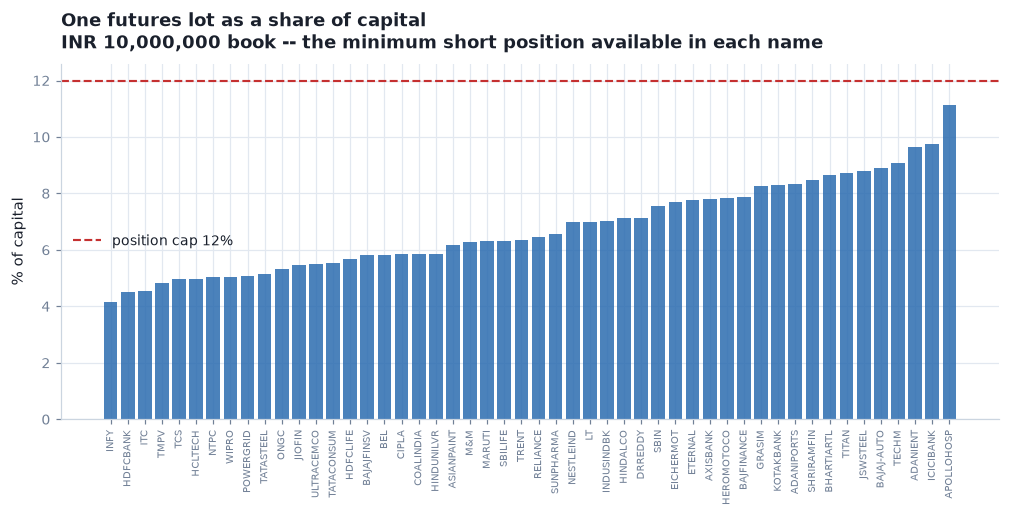

In [3]:
if lots_ok:
    fig, ax = plt.subplots(figsize=(11, 4.2))
    s = lt["pct_of_default_capital"].dropna().sort_values()
    ax.bar(range(len(s)), s.values, color=viz.PALETTE[0], alpha=0.85)
    ax.axhline(config.MAX_POSITION_WEIGHT * 100, color=viz.NEG, ls="--", lw=1.4,
               label=f"position cap {config.MAX_POSITION_WEIGHT:.0%}")
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels([t.replace(".NS", "") for t in s.index], rotation=90, fontsize=6.5)
    viz.title(ax, "One futures lot as a share of capital",
              f"INR {config.DEFAULT_CAPITAL:,.0f} book -- the minimum short position "
              f"available in each name")
    ax.set_ylabel("% of capital"); ax.legend()
    viz.save(fig, "09_lot_notional"); plt.show()

## 2. The index: how is the market positioned?

Put/call ratio by open interest and by volume, max pain, and the implied-volatility skew.

The two PCRs answer different questions: **OI** is positioning that has accumulated,
**volume** is what happened today. Max pain is computed properly — the settlement price
that minimises total intrinsic payout to option holders — not the common shortcut of taking
the highest-OI strike.

NIFTY 15-Sep-2026  |  spot 23,504.1  |  87 strikes  |  as of 2026-09-09 10:41:29
  PCR (open interest) 0.799   PCR (volume) 0.931
  max pain 23,600  (+0.41% from spot)
  ATM IV 10.75%   5% skew (put - call) +3.07 pts
  OI build +1,491,773 against a -4.33% move -> SHORT BUILDUP


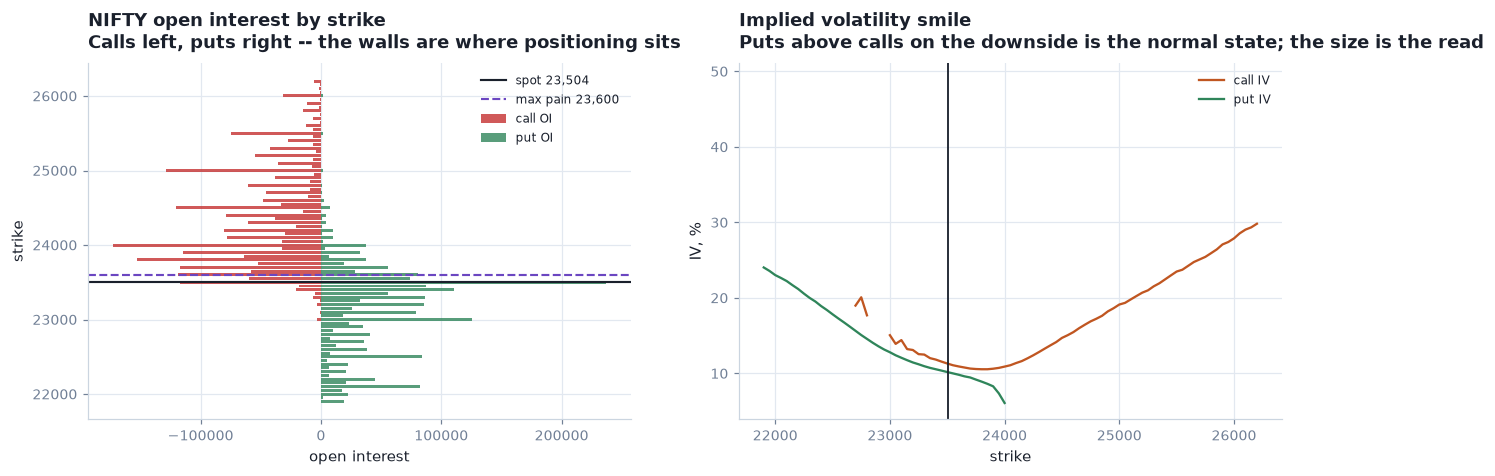

In [4]:
index_ok = True
try:
    nifty_chain = dv.option_chain("NIFTY", kind="index")
except Exception as exc:
    index_ok = False
    print(f"index option chain unavailable: {type(exc).__name__}: {str(exc)[:110]}")

if index_ok:
    spot = nifty_chain.attrs["underlying_value"]
    p = dv.pcr(nifty_chain)
    mp = dv.max_pain(nifty_chain)
    sk = dv.iv_skew(nifty_chain)
    nifty_row = dashboard.read().get("05_india_market", {}).get("nifty", {})
    chg = nifty_row.get("chg_30d_%", 0.0) or 0.0
    bu = dv.oi_buildup(nifty_chain, chg)

    print(f"NIFTY {nifty_chain.attrs['expiry']}  |  spot {spot:,.1f}  |  "
          f"{len(nifty_chain)} strikes  |  as of {nifty_chain.attrs.get('as_of')}")
    print(f"  PCR (open interest) {p['pcr_oi']:.3f}"
          f"   PCR (volume) {p['pcr_volume']:.3f}")
    print(f"  max pain {mp['max_pain']:,.0f}  ({mp['distance_%']:+.2f}% from spot)")
    print(f"  ATM IV {sk['atm_iv']:.2f}%   5% skew (put - call) {sk['skew']:+.2f} pts")
    print(f"  OI build {bu['net_oi_change']:+,.0f} against a {chg:+.2f}% move -> "
          f"{bu['buildup'].upper()}")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2))
    a1.barh(nifty_chain["strike"], -nifty_chain["CE_oi"], height=40,
            color=viz.NEG, alpha=0.8, label="call OI")
    a1.barh(nifty_chain["strike"], nifty_chain["PE_oi"], height=40,
            color=viz.POS, alpha=0.8, label="put OI")
    a1.axhline(spot, color=viz.INK, lw=1.4, label=f"spot {spot:,.0f}")
    a1.axhline(mp["max_pain"], color=viz.PALETTE[4], ls="--", lw=1.4,
               label=f"max pain {mp['max_pain']:,.0f}")
    viz.title(a1, "NIFTY open interest by strike",
              "Calls left, puts right -- the walls are where positioning sits")
    a1.set_xlabel("open interest"); a1.set_ylabel("strike"); a1.legend(fontsize=8)

    iv = nifty_chain[["strike", "CE_iv", "PE_iv"]].replace(0, np.nan).dropna(how="all")
    a2.plot(iv["strike"], iv["CE_iv"], lw=1.5, color=viz.PALETTE[1], label="call IV")
    a2.plot(iv["strike"], iv["PE_iv"], lw=1.5, color=viz.PALETTE[2], label="put IV")
    a2.axvline(spot, color=viz.INK, lw=1.2)
    viz.title(a2, "Implied volatility smile",
              "Puts above calls on the downside is the normal state; the size is the read")
    a2.set_xlabel("strike"); a2.set_ylabel("IV, %"); a2.legend(fontsize=8)
    viz.save(fig, "09_nifty_chain"); plt.show()

In [5]:
try:
    idx = fetch.nse_all_indices()
    vix_row = fetch.nse_index_row(config.INDIA_VIX, idx)
    if vix_row is not None:
        lo, hi = float(vix_row["yearLow"]), float(vix_row["yearHigh"])
        lvl = float(vix_row["last"])
        pos = (lvl - lo) / (hi - lo) * 100 if hi > lo else np.nan
        print(f"INDIA VIX {lvl:.2f}   52w range {lo:.2f}-{hi:.2f}   "
              f"at {pos:.0f}% of range")
        print(f"   regime: {'Complacent' if pos < 25 else 'Elevated' if pos > 75 else 'Normal'}")
    print("\nA VIX **term structure** would be the better read -- contango means the market")
    print("is paying up for protection further out. India VIX futures are not published in")
    print("any public JSON endpoint, so only the spot level is available. Stated rather")
    print("than approximated with something that is not a term structure.")
except Exception as exc:
    print(f"India VIX unavailable: {type(exc).__name__}: {str(exc)[:90]}")

INDIA VIX 11.69   52w range 8.72-28.91   at 15% of range
   regime: Complacent

A VIX **term structure** would be the better read -- contango means the market
is paying up for protection further out. India VIX futures are not published in
any public JSON endpoint, so only the spot level is available. Stated rather
than approximated with something that is not a term structure.


## 3. Name-level crowding

Option chains for the long and short candidates. This is the slow section — two calls per
name — and every failure is reported rather than skipped.

In [6]:
filt_path = config.OUTPUT_DIR / "nifty50_screen_filtered.csv"
data = dashboard.read()
short_block = data.get("08_earnings_quality", {}).get("short_candidates", {})

if filt_path.exists() and short_block:
    filtered = pd.read_csv(filt_path, index_col=0)
    longs = list(filtered.nsmallest(6, "rank_filtered").index)
    shorts = list(short_block)[:6]
else:
    raise FileNotFoundError("run notebook 08 first -- 09 reads its long and short lists")

names = [t for t in dict.fromkeys(longs + shorts)]
side_of = {**{t: "long" for t in longs}, **{t: "short" for t in shorts}}
print(f"probing {len(names)} names: {len(longs)} long, {len(shorts)} short candidates\n")

snapshot = None
try:
    snapshot = dv.futures_snapshot()
    print(f"futures snapshot: {snapshot['underlying'].nunique()} underlyings published")
except Exception as exc:
    print(f"futures snapshot unavailable: {type(exc).__name__}: {str(exc)[:80]}")

screen_all = pd.read_csv(config.OUTPUT_DIR / "nifty50_screen.csv", index_col=0)
rows, failed = [], []
for t in names:
    chg = float(pd.to_numeric(screen_all["ret_3m_%"].get(t), errors="coerce") or 0.0)
    chain = None
    try:
        chain = dv.option_chain(t)
    except Exception as exc:
        failed.append((t, f"{type(exc).__name__}: {str(exc)[:70]}"))
    row = dv.crowding_row(t, chain=chain, snapshot=snapshot, price_change_pct=chg)
    row["ticker"] = t
    row["side"] = side_of[t]
    row["sector"] = config.NIFTY_50.get(t, "")
    rows.append(row)

crowd = pd.DataFrame(rows).set_index("ticker")
if failed:
    print(f"\n{len(failed)} option chain(s) unavailable:")
    display(pd.DataFrame(failed, columns=["ticker", "reason"]))

crowd["crowding_score"] = dv.crowding_score(crowd)
cols = [c for c in ("side", "sector", "pcr_oi", "pcr_volume", "atm_iv", "skew",
                    "max_pain_distance_%", "net_oi_change", "buildup", "basis_%",
                    "annualised_carry_%", "rollover_%", "crowding_score")
        if c in crowd.columns]
display(crowd[cols].round(3))

coverage = pd.Series({
    "option chain": int(crowd["pcr_oi"].notna().sum()) if "pcr_oi" in crowd else 0,
    "futures basis": int(crowd["basis_%"].notna().sum()) if "basis_%" in crowd else 0,
    "rollover": int(crowd["rollover_%"].notna().sum()) if "rollover_%" in crowd else 0,
    "names probed": len(crowd),
})
display(coverage.to_frame("names"))
print("Futures coverage is thin by construction: NSE publishes futures for only ~25")
print("underlyings, so basis and rollover exist for whichever of our names happen to be")
print("among them. Reported, not silently dropped.")

probing 12 names: 6 long, 6 short candidates

futures snapshot: 24 underlyings published


,side,sector,pcr_oi,pcr_volume,atm_iv,skew,max_pain_distance_%,net_oi_change,buildup,basis_%,annualised_carry_%,crowding_score
ticker,,,,,,,,,,,,
KOTAKBANK.NS,long,Financial Services,0.61,0.86,16.45,2.29,1.39,"-1,149.00",short covering,NaN,NaN,75.00
COALINDIA.NS,long,Oil Gas & Fuels,0.86,0.63,17.66,2.27,-2.82,"7,852.00",short buildup,0.38,6.95,25.00
ADANIPORTS.NS,long,Services,0.79,0.40,20.35,-0.10,-3.51,"2,421.00",short buildup,0.38,6.98,50.00
ICICIBANK.NS,long,Financial Services,0.64,0.81,16.25,1.72,2.37,"3,037.00",long buildup,0.58,10.51,88.89
JSWSTEEL.NS,long,Metals & Mining,0.65,0.47,20.15,-1.64,-0.30,-4.00,short covering,NaN,NaN,50.00
TITAN.NS,long,Consumer Durables,0.68,0.83,16.95,7.38,0.34,485.00,long buildup,NaN,NaN,33.33
TMPV.NS,short,Automobile,0.65,0.43,24.27,0.64,5.89,11.00,short buildup,NaN,NaN,58.33
DRREDDY.NS,short,Healthcare,0.60,0.56,19.57,1.39,3.38,268.00,short buildup,NaN,NaN,83.33
HINDUNILVR.NS,short,FMCG,0.58,0.44,16.16,0.01,2.22,788.00,short buildup,NaN,NaN,91.67


,names
option chain,12
futures basis,3
rollover,0
names probed,12


Futures coverage is thin by construction: NSE publishes futures for only ~25
underlyings, so basis and rollover exist for whichever of our names happen to be
among them. Reported, not silently dropped.


## 4. The squeeze check

A crowded long is expensive. A crowded short is dangerous — that is where a rally forces
buying and the position moves against you fastest.

The score is **relative to the names probed today**, not a historical percentile. With one
snapshot there is no percentile to give.

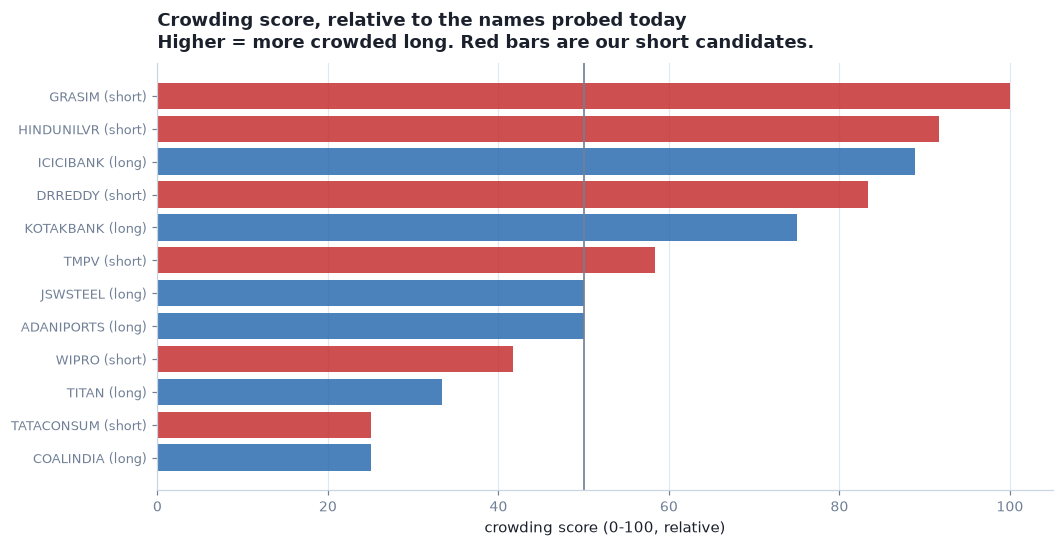

SQUEEZE RISK -- short candidates that already look crowded long:
   GRASIM         Construction Materials   crowding 100, PCR 0.52
   HINDUNILVR     FMCG                     crowding 92, PCR 0.58
   DRREDDY        Healthcare               crowding 83, PCR 0.60

   Shorting into a crowded long is how a thesis that is right on the
   fundamentals still loses money on the timing.

Uncrowded longs (cheaper to own): TITAN, COALINDIA


In [7]:
ranked = crowd.dropna(subset=["crowding_score"]).sort_values("crowding_score",
                                                             ascending=False)
if len(ranked):
    fig, ax = plt.subplots(figsize=(10.5, max(3.4, 0.42 * len(ranked))))
    vals = ranked["crowding_score"].sort_values()
    colors = [viz.NEG if ranked.loc[t, "side"] == "short" else viz.PALETTE[0]
              for t in vals.index]
    ax.barh(range(len(vals)), vals.values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([f"{t.replace('.NS', '')} ({ranked.loc[t, 'side']})"
                        for t in vals.index], fontsize=8.5)
    ax.axvline(50, color=viz.MUTED, lw=1.1); ax.grid(axis="y", visible=False)
    viz.title(ax, "Crowding score, relative to the names probed today",
              "Higher = more crowded long. Red bars are our short candidates.")
    ax.set_xlabel("crowding score (0-100, relative)")
    viz.save(fig, "09_crowding"); plt.show()

    crowded_shorts = ranked[(ranked["side"] == "short") &
                            (ranked["crowding_score"] > 60)]
    if len(crowded_shorts):
        print("SQUEEZE RISK -- short candidates that already look crowded long:")
        for t, r in crowded_shorts.iterrows():
            bits = [f"crowding {r['crowding_score']:.0f}"]
            if np.isfinite(r.get("basis_%", np.nan)):
                bits.append(f"basis {r['basis_%']:+.2f}%")
            if np.isfinite(r.get("pcr_oi", np.nan)):
                bits.append(f"PCR {r['pcr_oi']:.2f}")
            print(f"   {t.replace('.NS', ''):14s} {r['sector']:24s} " + ", ".join(bits))
        print("\n   Shorting into a crowded long is how a thesis that is right on the")
        print("   fundamentals still loses money on the timing.")
    else:
        print("No short candidate looks crowded long on today's snapshot.")

    cheap_longs = ranked[(ranked["side"] == "long") & (ranked["crowding_score"] < 40)]
    if len(cheap_longs):
        print(f"\nUncrowded longs (cheaper to own): "
              f"{', '.join(t.replace('.NS', '') for t in cheap_longs.index)}")
else:
    print("No crowding score could be computed -- see the coverage table above.")

## 5. Accumulate the history

NSE publishes only the current state and there is no OI history API — the same wall
notebook 05 hit with FII/DII flows, and the same response: save what each run sees.

`data/derivatives_history.csv` is deliberately **outside** `data/cache/`. Clearing the
cache is safe; deleting this loses history that cannot be reconstructed.

In [8]:
hist = dv.append_history(crowd.reset_index())
sessions = hist.attrs["sessions"]
print(f"{hist.attrs['path']}")
print(f"   {len(hist)} rows across {sessions} session(s), "
      f"{hist['symbol'].nunique()} symbols")
if sessions < 20:
    print(f"\n   {sessions} session(s) is not yet a distribution. Once this has accumulated")
    print("   a few months, crowding_score can become a genuine historical percentile")
    print("   instead of a same-day ranking. Until then it ranks names against each other.")
else:
    print(f"\n   {sessions} sessions accumulated -- enough to start reading percentiles.")

G:\stock market analysis\data\derivatives_history.csv
   15 rows across 1 session(s), 15 symbols

   1 session(s) is not yet a distribution. Once this has accumulated
   a few months, crowding_score can become a genuine historical percentile
   instead of a same-day ranking. Until then it ranks names against each other.


In [9]:
payload = {
    "signal": (f"{len(ranked)} names scored, "
               f"{int((ranked['side'] == 'short').sum()) if len(ranked) else 0} short "
               f"candidates checked for squeeze risk"),
    "score": (round(float(ranked["crowding_score"].mean()), 2) if len(ranked) else None),
    "as_of": str(pd.Timestamp.now().normalize().date()),
    "sources_ok": f"{n_ok}/{len(health)}",
    "lot_sizes_live": bool(lots_ok),
    "lot_divergence_vs_fallback": (int(lt.attrs["n_diverged"]) if lots_ok else None),
    "fno_eligible": (int(lt["fno_eligible"].sum()) if lots_ok else None),
    "lot_pct_of_capital": ({"min": round(float(lt["pct_of_default_capital"].min()), 2),
                            "median": round(float(lt["pct_of_default_capital"].median()), 2),
                            "max": round(float(lt["pct_of_default_capital"].max()), 2)}
                           if lots_ok else None),
    "nifty_options": ({"expiry": nifty_chain.attrs["expiry"],
                       "spot": float(spot),
                       "pcr_oi": round(float(p["pcr_oi"]), 3),
                       "pcr_volume": round(float(p["pcr_volume"]), 3),
                       "max_pain": float(mp["max_pain"]),
                       "max_pain_distance_%": round(float(mp["distance_%"]), 2),
                       "atm_iv": round(float(sk["atm_iv"]), 2),
                       "skew": round(float(sk["skew"]), 2),
                       "buildup": bu["buildup"]} if index_ok else None),
    "coverage": {str(k): int(v) for k, v in coverage.items()},
    "crowding": {t: round(float(r), 1)
                 for t, r in ranked["crowding_score"].items()} if len(ranked) else {},
    "squeeze_risk": (list(crowded_shorts.index) if len(ranked) and len(crowded_shorts)
                     else []),
    "history_sessions": int(sessions),
    "unavailable": ["delivery % (quote-equity trade_info returns 403)",
                    "India VIX term structure (no public futures endpoint)",
                    "official NSE rollover (not in any public JSON)"],
    "exports": ["outputs/fno_lots.csv", "data/derivatives_history.csv"],
}
dashboard.append("09_positioning", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:20:08
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 10

`outputs/fno_lots.csv` — the live lot size and F&O eligibility for every name in the
universe. Notebook 10 reads it and, failing that, falls back to
`config.LOT_SIZE_FALLBACK`. Today those two agree exactly, which is the cross-check that
tells you the fallback is still current.

The crowding read is an **overlay, not a gate**. It does not remove names from either list;
it says which positions will be more expensive to hold and which shorts carry squeeze risk.
That is a sizing input and a timing caution, and notebook 10 sizes with it in view.

If this notebook could not run at all, notebook 10 is unaffected apart from using a dated
lot table, and `dashboard.summary()` simply skips the missing section. That degradation was
designed in, because these endpoints will break again.